In [6]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd,numpy as np,matplotlib.pylab as plt,seaborn as sns


In [8]:
df= pd.read_csv("../datasets/Crop_recommendation.csv")

In [9]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [11]:
df.isnull()

,N,P,K,temperature,humidity,ph,rainfall,label
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [12]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [13]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2195    False
2196    False
2197    False
2198    False
2199    False
Length: 2200, dtype: bool

In [14]:
df.duplicated().sum()

np.int64(0)

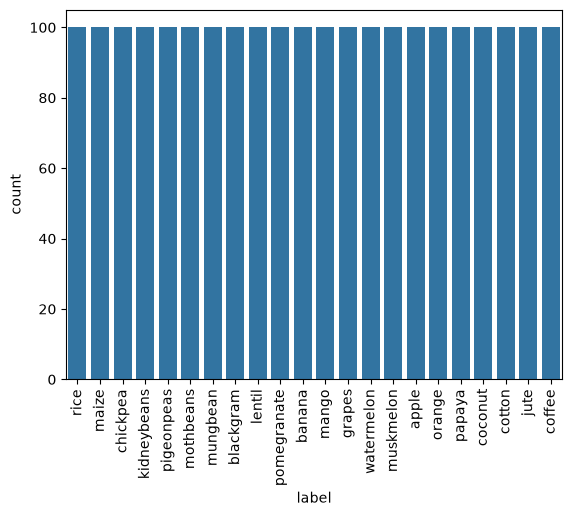

In [15]:
plt.Figure(figsize=(12,6))
sns.countplot(x="label",data=df)
plt.xticks(rotation=90)
plt.show()

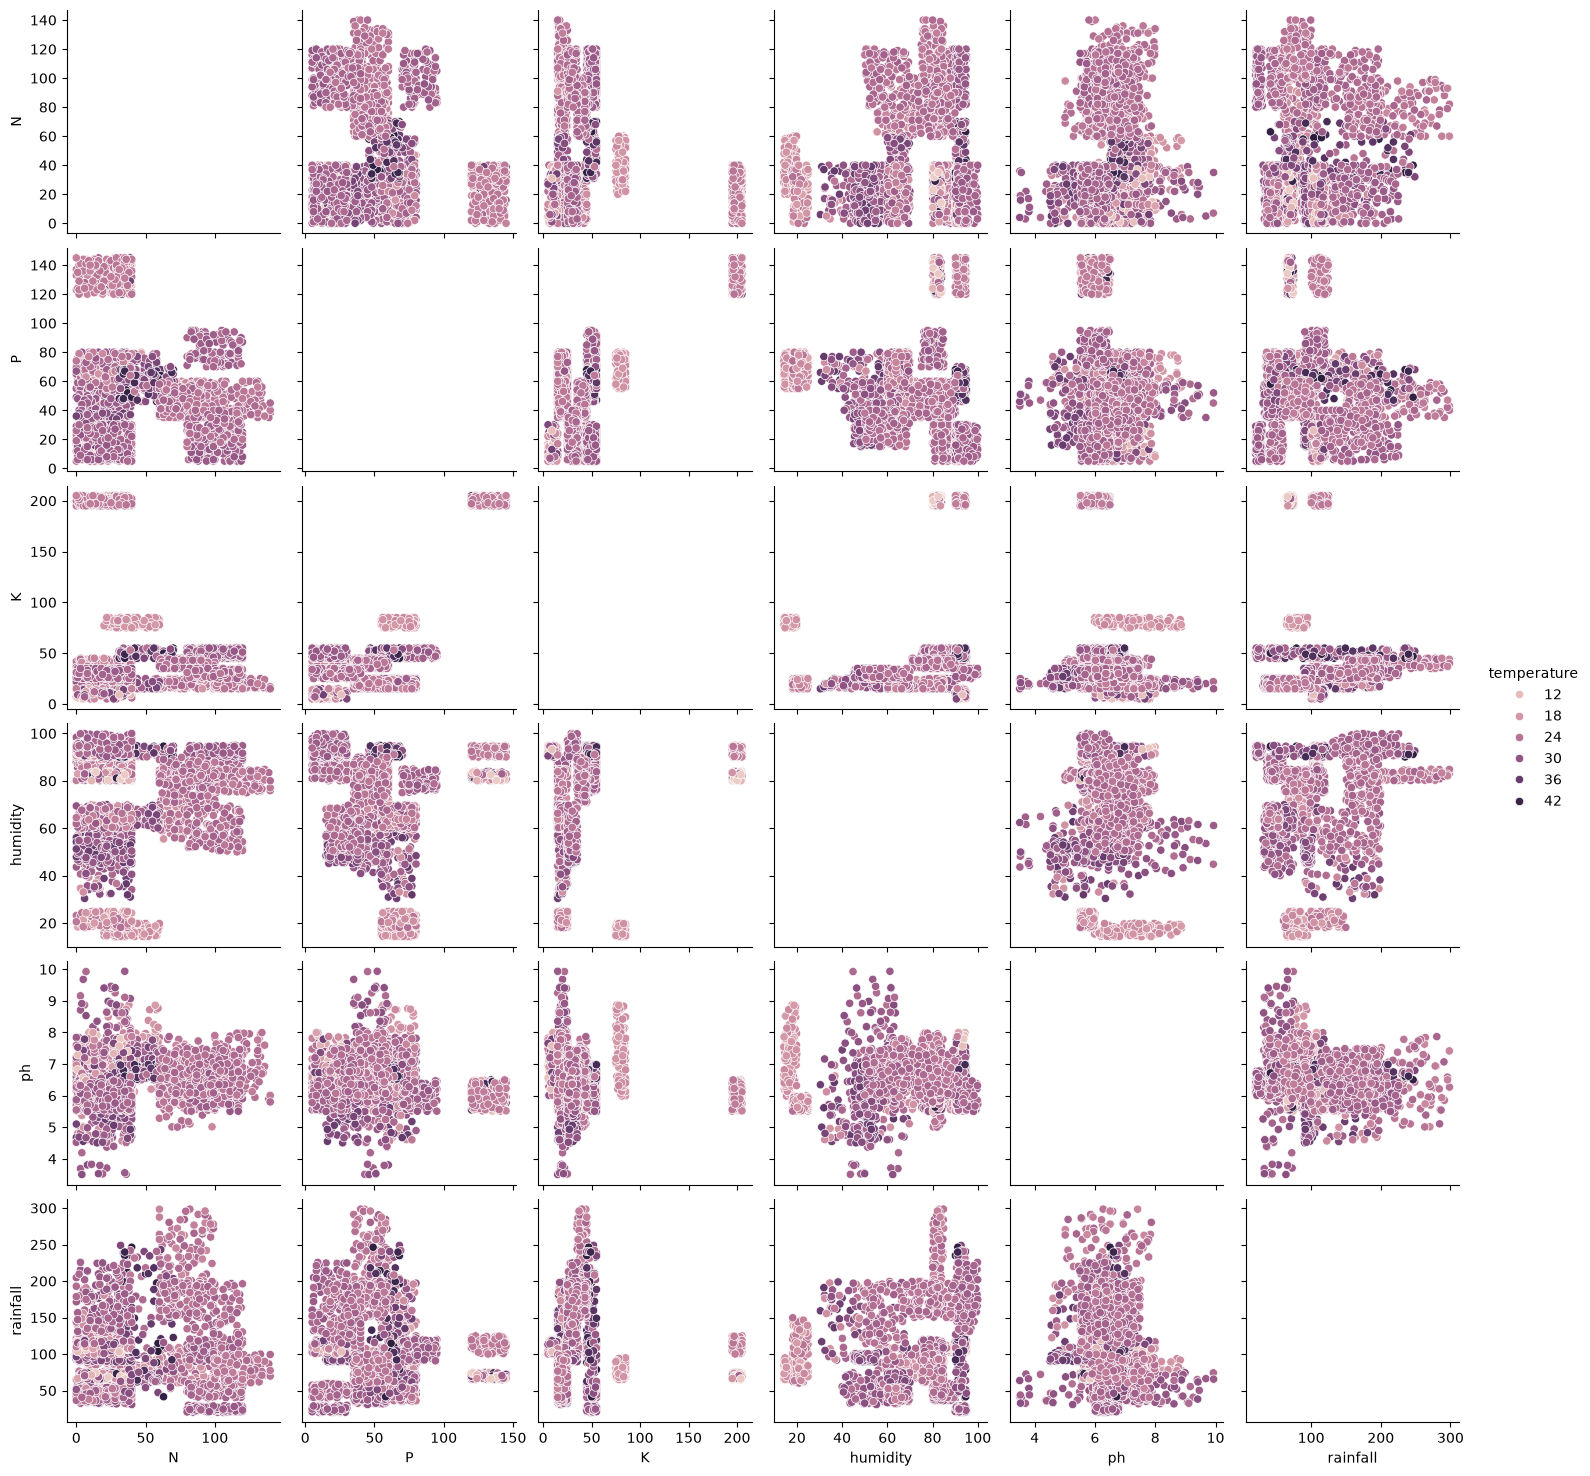

In [16]:
sns.pairplot(df,kind="scatter",hue="temperature")

<Axes: >

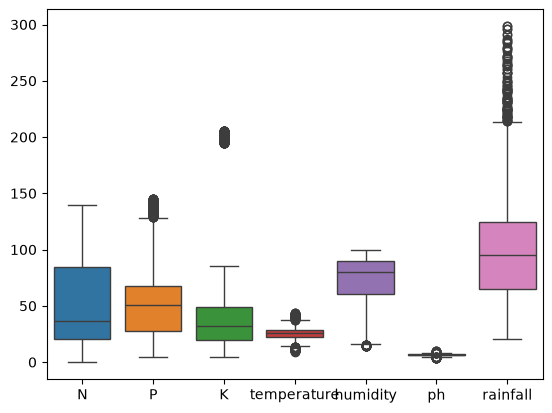

In [17]:
sns.boxplot(data=df.drop(columns="label"))

<Axes: >

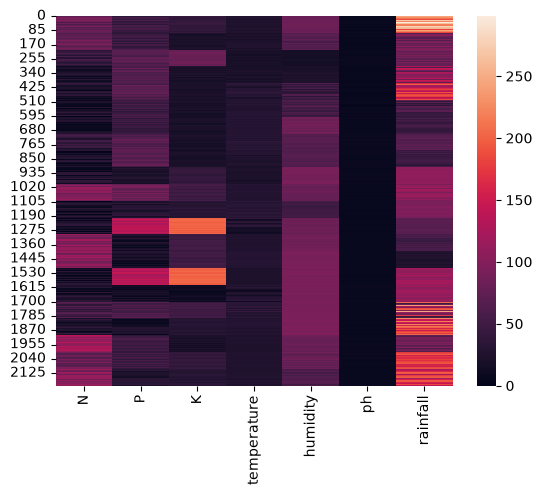

In [18]:
sns.heatmap(data=df.drop(columns="label"))

In [19]:
sns.pairplot(df,kind="scatter",hue="temperature").corr(),annot=True)

SyntaxError: unmatched ')' (3599500869.py, line 1)

KeyError: 'lables'

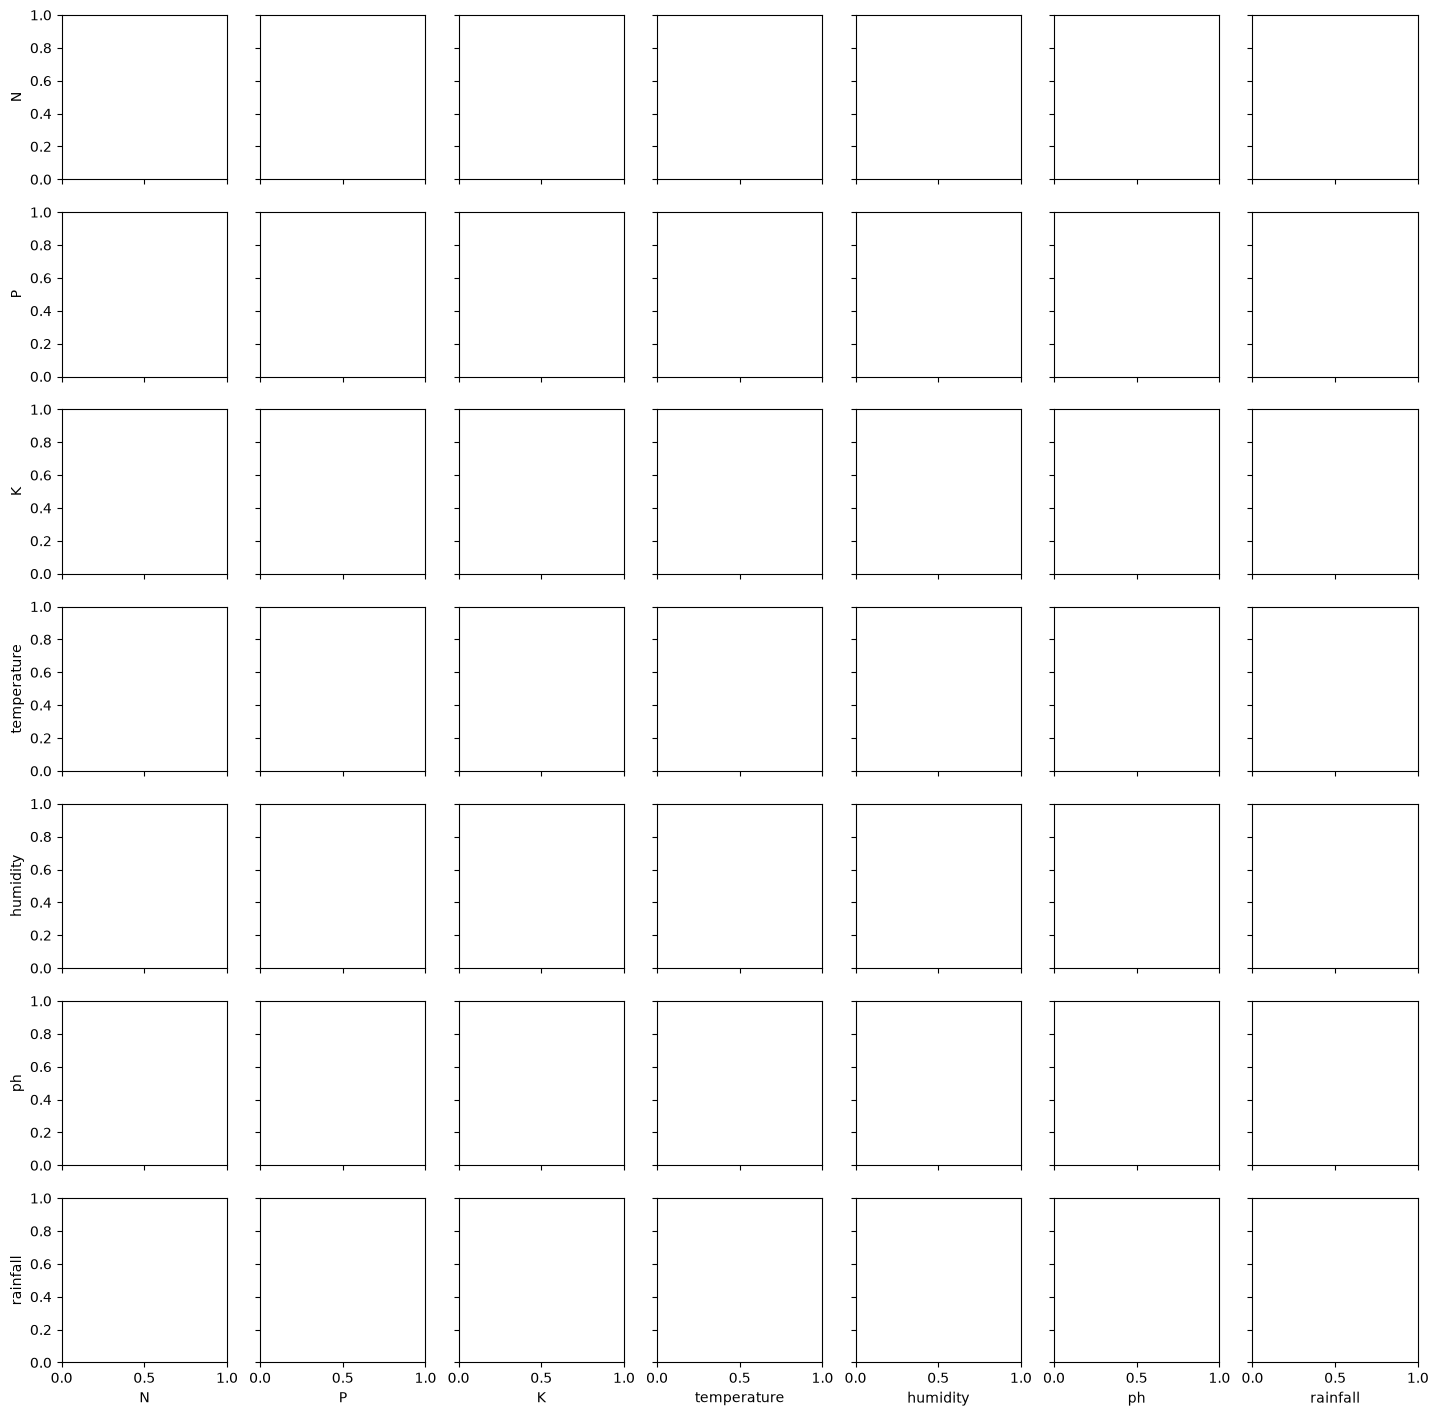

In [ ]:
sns.pairplot(df,hue="lables").corr(),annot=true

In [ ]:
X=df.drop("label",axis=1)
Y=df["label"]

In [ ]:
pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- --------------------

In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
encoder=LabelEncoder()
y = encoder.fit_transform(df['label'])

In [24]:
import pickle 


In [25]:
pickle.dump(encoder, open("../models/crop_label_encoder.pkl","wb"))


In [26]:
x=df.drop("label",axis=1)
y=df["label"]

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [29]:
pickle.dump(scaler,open("../models/standard_scaler.pkl","wb"))

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
svm_model=SVC(kernel='linear',random_state=42)
svm_model.fit(x_train,y_train)
pre=svm_model.predict(x_test)
print("Accuracy:",svm_model.score(x_test,y_test))
# pickle.dump(svm_model,open('../models/svm_model.pkl','wb'))

Accuracy: 0.9681818181818181


In [ ]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
pre=knn_model.predict(x_test)
print("Accuracy:",knn_model.score(x_test,y_test))
# pickle.dump(knn_model,open('../models/knn_model.pkl','wb'))

Accuracy: 0.9431818181818182


In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(random_state=42)
lr_model.fit(x_train,y_train)
pre=lr_model.predict(x_test)
print("Accuracy:",lr_model.score(x_test,y_test))
# pickle.dump(lr_model,open('../models/logistic_regression_model.pkl','wb'))

Accuracy: 0.9545454545454546


In [37]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
pre=model.predict(x_test)
print("Accuracy:",model.score(x_test,y_test))
pickle.dump(model,open('../models/best_modelrandom_forest_model.pkl','wb'))

Accuracy: 0.9818181818181818
